In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/16
    print("準備完了！このまま下のセルを実行できます。")

# 第16章 連続潜在変数 (Continuous Latent Variables)
## 16.2 確率的潜在変数 (Probabilistic Latent Variables)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第16章「連続潜在変数」の第16.2節「確率的潜在変数 (Probabilistic Latent Variables)」の完全な理論解説、数式展開、Python実装、および忠実な図版再現（Figure 16.7 〜 16.9）を提供します。

---

### 目次
1. **はじめに：確率的主成分分析 (PPCA) の動機と利点**
   - 決定論的PCAから生成モデルへのパラダイムシフト
   - 確率的モデル化がもたらす8大メリット
2. **16.2.1 生成モデル (Generative Model)**
   - 潜在変数事前分布 $p(\mathbf{z})$ と条件付き観測分布 $p(\mathbf{x} \mid \mathbf{z})$（式 16.31, 16.32）
   - 生成過程 $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}$（式 16.33）
   - パンケーキ型確率密度の幾何学的直観（Figure 16.7）
3. **16.2.2 尤度関数 (Likelihood Function)**
   - 周辺分布 $p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \mathbf{C})$ と共分散 $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}$ の厳密導出（式 16.34 〜 16.39）
   - 潜在空間の回転不変性と統計的非識別性（式 16.40）
   - ウッドベリーの逆行列公式による計算量削減 $\mathcal{O}(D^3) \to \mathcal{O}(M^3)$（式 16.41, 16.42）
   - 事後分布 $p(\mathbf{z} \mid \mathbf{x})$ の導出（式 16.43）
4. **16.2.3 最尤推定 (Maximum Likelihood)**
   - 有向確率的グラフィカルモデル（Figure 16.8）
   - 対数尤度関数の標本共分散 $\mathbf{S}$ による表現（式 16.44, 16.45）
   - Tipping & Bishop (1999) による厳密閉形式解 $\mathbf{W}_{\text{ML}}$ と $\sigma_{\text{ML}}^2$ の証明（式 16.46, 16.47）
   - $M=D$ での一般正規分布への一致（式 16.48）
   - 潜在空間への事後射影と正則化・縮小推定効果（式 16.49 〜 16.51）
   - 自由度 / 独立パラメータ数の算定（式 16.52）
5. **16.2.4 因子分析 (Factor Analysis)**
   - 対角ノイズ共分散 $\mathbf{\Psi}$ の導入（式 16.53, 16.54）
   - 座標系の拡大縮小不変性とPPCAとの対比
   - EMアルゴリズムによるパラメータ学習
6. **16.2.5 独立成分分析 (Independent Component Analysis: ICA)**
   - 非ガウス型潜在変数による因子分解事前分布（式 16.55）
   - ガウス潜在変数における回転不変性の限界とブラインド信号源分離
   - 裾の重い分布（式 16.56）とFastICAアルゴリズムの実証
7. **16.2.6 カルマンフィルタ (Kalman Filters / Linear Dynamical Systems)**
   - 時系列データへのマルコフ連鎖拡張（Figure 16.9）
   - 隠れマルコフモデル (HMM) との深い構造的対応
   - 1次元状態空間モデルのフィルタリング実証


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "16" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.probabilistic_latent_variables import (
    ProbabilisticPCA,
    FactorAnalysisModel,
    FastICA2D,
    KalmanFilter1D,
    generate_figure_16_7,
    generate_figure_16_8,
    generate_figure_16_9,
)

setup_style()
print("Setup complete. Chapter 16 Section 16.2 modules loaded successfully.")


Setup complete. Chapter 16 Section 16.2 modules loaded successfully.


## 1. 確率的潜在変数モデルの動機と生成モデル (16.2.1 Generative Model)

前節（16.1節）で学んだ従来の主成分分析 (PCA) は、高次元データ $\mathbf{x} \in \mathbb{R}^D$ を直交射影によって低次元部分空間 $\mathbb{R}^M$ ($M < D$) に線形写像する決定論的（非確率的）手法でした。しかし、PCAを**確率的潜在変数モデル（probabilistic latent-variable model）**として再定式化した**確率的主成分分析 (Probabilistic PCA: PPCA)**（Tipping & Bishop 1997, 1999; Roweis 1998）は、従来のPCAに対して極めて強力な利点をもたらします：

1. **自由度の制御**: 完全共分散行列の $\mathcal{O}(D^2)$ のパラメータ爆発を防ぎつつ、データ内の主要な相関を保持した正規分布を構築できる。
2. **効率的なEMアルゴリズム**: 高次元空間において全データ共分散行列 $\mathbf{S}$ を明示的に計算することなく、主要な主成分を高速に計算できる。
3. **欠損値処理 (Missing Data)**: 観測データの一部が欠損していても、EMアルゴリズムの枠組みで自然に対処可能。
4. **混合モデルへの拡張**: 複数のPPCAを組み合わせた「PPCA混合モデル (Mixtures of PPCA)」を定式化し、局所線形多様体を柔軟に表現できる。
5. **モデル比較の確率的評価**: 尤度関数 $p(\mathbf{X})$ が明示的に定義されるため、赤池情報量規準 (AIC) やベイズ情報量規準 (BIC) 等で他モデルと比較できる。
6. **クラス条件付き確率**: 生成的分類器として直接利用可能。
7. **生成サンプリング**: 学習済みモデルから新たな合成データを無制限に生成可能。
8. **ベイズ的主成分分析の基礎**: 主部分空間の有効次元数 $M$ をデータから自動決定するベイズ的拡張の土台となる。

---

### 16.2.1 生成モデルの数学的定義

PPCAは、すべての周辺分布・条件付き分布がガウス分布に従う**線形ガウスモデル (linear-Gaussian model)** の代表例です。
$M$ 次元の連続潜在変数 $\mathbf{z} \in \mathbb{R}^M$ に対し、ゼロ平均・単位共分散行列の標準正規分布を事前分布（prior distribution）として仮定します：

$$
p(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I}_M) \tag{16.31}
$$

観測データ $\mathbf{x} \in \mathbb{R}^D$ の潜在変数 $\mathbf{z}$ に対する条件付き分布（conditional distribution）は、線形変換 $\mathbf{W}\mathbf{z} + \boldsymbol{\mu}$ を中心とし、等方性（isotropic）ノイズ分散 $\sigma^2 \mathbf{I}_D$ を持つガウス分布として定義されます：

$$
p(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(\mathbf{x} \mid \mathbf{W}\mathbf{z} + \boldsymbol{\mu}, \sigma^2 \mathbf{I}_D) \tag{16.32}
$$

ここで、パラメータは以下の通りです：
- $\mathbf{W} \in \mathbb{R}^{D \times M}$: 因子負荷量行列（factor loadings matrix）。その列ベクトル群はデータ空間内の $M$ 次元主部分空間を張る。
- $\boldsymbol{\mu} \in \mathbb{R}^D$: 観測データの平均ベクトル。
- $\sigma^2 > 0$: 主部分空間に直交する方向（および空間全体）の等方性ノイズ分散。

このモデルは、以下の**生成過程（generative process）**として直観的に理解できます：

$$
\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_D) \tag{16.33}
$$

潜在変数 $\mathbf{z}$ とノイズ $\boldsymbol{\epsilon}$ は互いに独立です。
これは、潜在空間 $\mathbb{R}^M$ 上の各点 $\mathbf{z}$ に対し、データ空間内のアフィン部分空間 $\mathbf{W}\mathbf{z} + \boldsymbol{\mu}$ 上を等方性ガウス「スプレー缶」を動かしながらインクを吹き付ける操作に相当します。吹き付けられたインクの重なり合いによって、主部分空間に沿って平たく伸びた**パンケーキ型（pancake-shaped）**の周辺分布 $p(\mathbf{x})$ が形成されます。

下図（Figure 16.7）は、2次元データ空間 ($D=2$) と1次元潜在空間 ($M=1$) におけるこの生成過程を可視化したものです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_7_ppca_generative_model.png and /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_7_ppca_generative_model.png


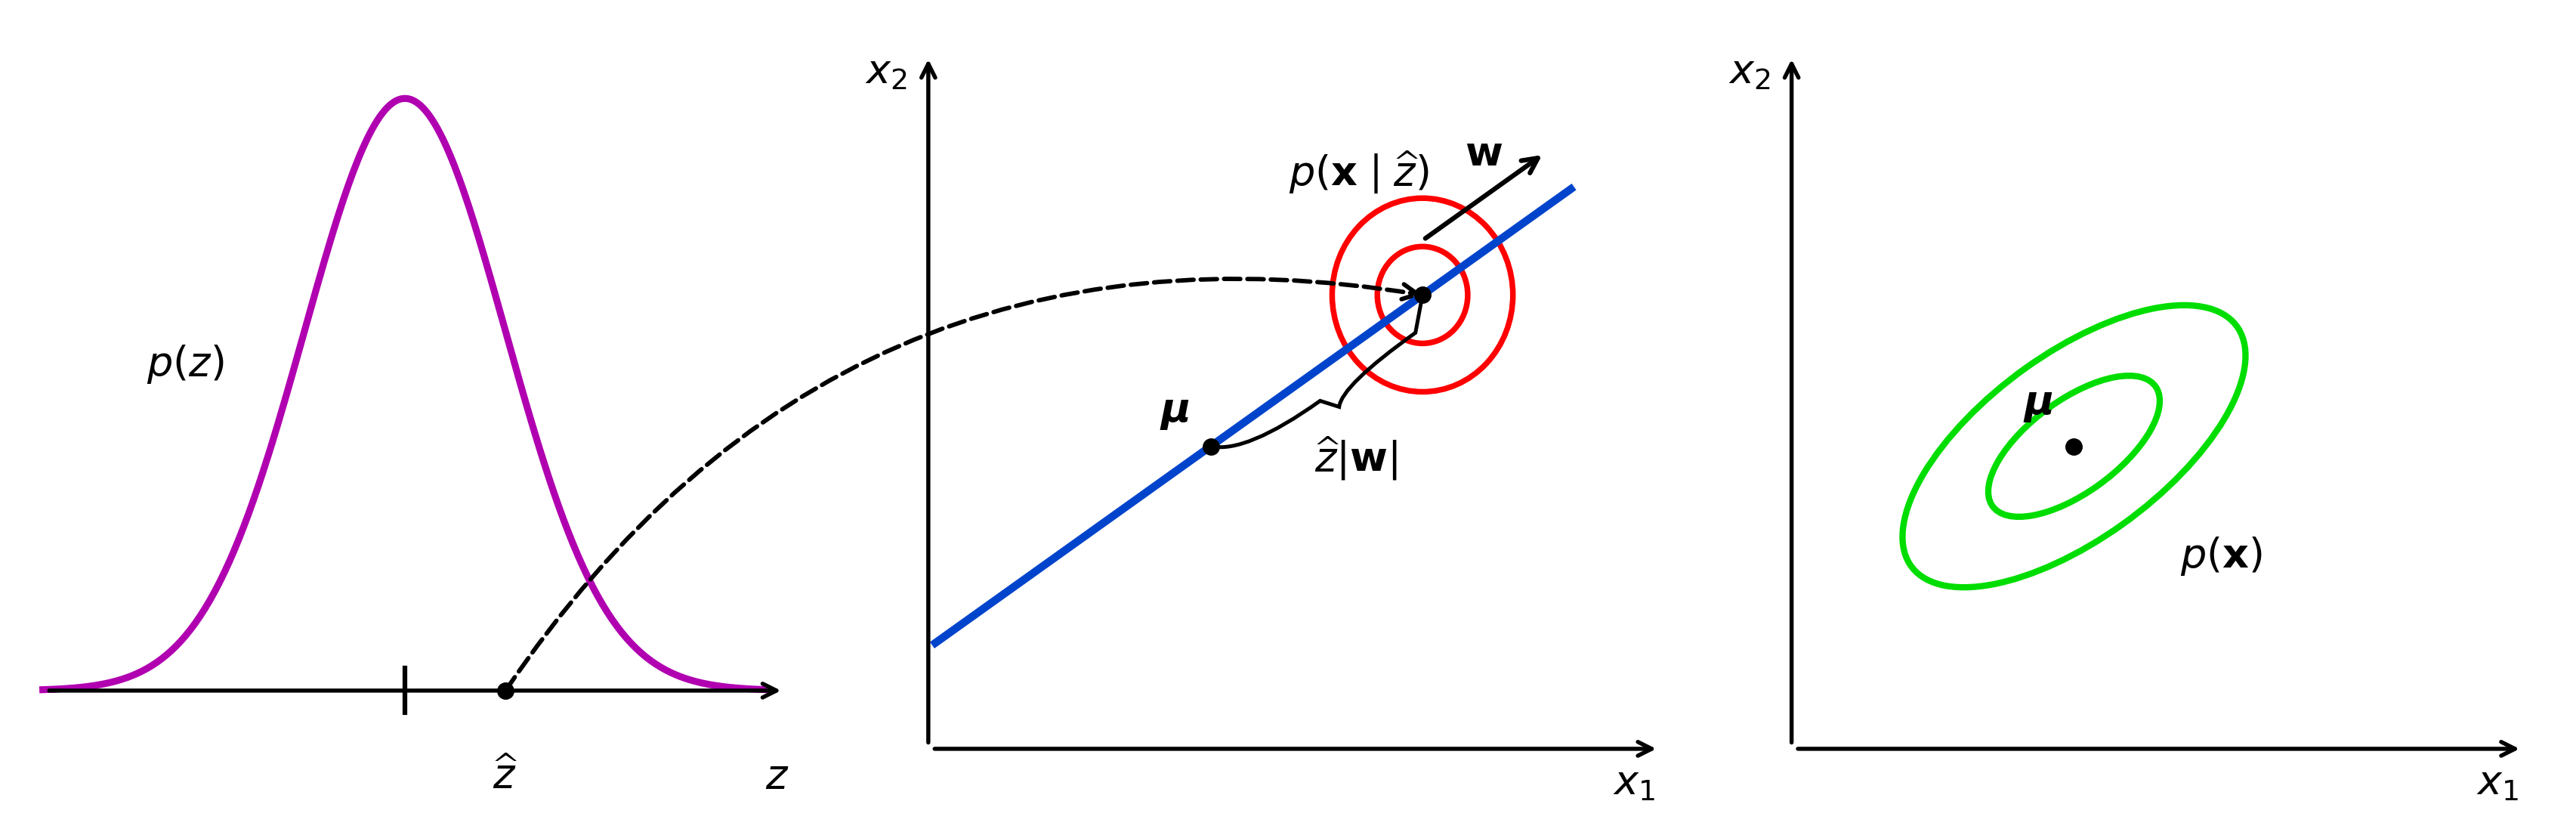

In [2]:
# Figure 16.7: 確率的主成分分析の生成モデル
fig16_7 = generate_figure_16_7()
plt.show()


## 2. 16.2.2 尤度関数 (Likelihood Function)

観測データ $\mathbf{x}$ の周辺確率密度 $p(\mathbf{x})$ は、確率の加法定理と乗法定理により、潜在変数 $\mathbf{z}$ を周辺化（積分消去）することで得られます：

$$
p(\mathbf{x}) = \int p(\mathbf{x} \mid \mathbf{z}) p(\mathbf{z}) \, d\mathbf{z} \tag{16.34}
$$

線形ガウスモデルの畳み込み積分公式（第2章 式 2.122 〜 2.123）より、この積分は解析的に実行可能であり、結果は再びガウス分布となります：

$$
p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \mathbf{C}) \tag{16.35}
$$

周辺共分散行列 $\mathbf{C} \in \mathbb{R}^{D \times D}$ は以下のように定義されます：

$$
\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D \tag{16.36}
$$

#### 【厳密導出】：期待値と共分散の直接計算
生成方程式 $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}$ より、$\mathbb{E}[\mathbf{z}] = \mathbf{0}, \mathbb{E}[\boldsymbol{\epsilon}] = \mathbf{0}$ かつ $\mathbf{z}$ と $\boldsymbol{\epsilon}$ が無相関であることから：

$$
\mathbb{E}[\mathbf{x}] = \mathbb{E}[\mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}] = \mathbf{W}\mathbb{E}[\mathbf{z}] + \boldsymbol{\mu} + \mathbb{E}[\boldsymbol{\epsilon}] = \boldsymbol{\mu} \tag{16.37}
$$

共分散行列は：

$$
\begin{aligned}
\operatorname{cov}[\mathbf{x}] &= \mathbb{E}[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^\top] \\
&= \mathbb{E}[(\mathbf{W}\mathbf{z} + \boldsymbol{\epsilon})(\mathbf{W}\mathbf{z} + \boldsymbol{\epsilon})^\top] \tag{16.38} \\
&= \mathbf{W} \mathbb{E}[\mathbf{z}\mathbf{z}^\top] \mathbf{W}^\top + \mathbf{W}\mathbb{E}[\mathbf{z}\boldsymbol{\epsilon}^\top] + \mathbb{E}[\boldsymbol{\epsilon}\mathbf{z}^\top]\mathbf{W}^\top + \mathbb{E}[\boldsymbol{\epsilon}\boldsymbol{\epsilon}^\top] \\
&= \mathbf{W} \mathbf{I}_M \mathbf{W}^\top + \sigma^2 \mathbf{I}_D \\
&= \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D \tag{16.39}
\end{aligned}
$$

このように、独立なガウス分布の和において分散が加法的に合成される性質が明快に現れています。

---

### 潜在空間の回転不変性 (Rotational Invariance)

任意の $M \times M$ 直交行列 $\mathbf{R}$ ($\mathbf{R}\mathbf{R}^\top = \mathbf{I}_M$) に対して、変換 $\widetilde{\mathbf{W}} = \mathbf{W}\mathbf{R}$ を施すと：

$$
\widetilde{\mathbf{W}}\widetilde{\mathbf{W}}^\top = \mathbf{W}\mathbf{R}\mathbf{R}^\top\mathbf{W}^\top = \mathbf{W}\mathbf{W}^\top \tag{16.40}
$$

したがって、共分散行列 $\mathbf{C}$、および周辺密度 $p(\mathbf{x})$ は $\mathbf{R}$ の選び方に一切依存せず不変です。これは潜在空間における座標系の回転に対する統計的非識別性（non-identifiability）を意味します。

---

### ウッドベリーの公式による逆行列と行列式の高速計算

周辺尤度の評価には $\mathbf{C}^{-1}$ および行列式 $|\mathbf{C}|$ が必要ですが、$D \times D$ 行列の直接反転は $\mathcal{O}(D^3)$ の計算量を要します。
ここで**ウッドベリーの逆行列恒等式 (Woodbury matrix inversion identity)**：

$$
(\mathbf{A} + \mathbf{U}\mathbf{V}^\top)^{-1} = \mathbf{A}^{-1} - \mathbf{A}^{-1}\mathbf{U}(\mathbf{I} + \mathbf{V}^\top \mathbf{A}^{-1}\mathbf{U})^{-1}\mathbf{V}^\top \mathbf{A}^{-1}
$$

を $\mathbf{A} = \sigma^2 \mathbf{I}_D, \mathbf{U} = \mathbf{W}, \mathbf{V} = \mathbf{W}$ に適用すると：

$$
\mathbf{C}^{-1} = \sigma^{-2} \mathbf{I}_D - \sigma^{-2}\mathbf{W}\mathbf{M}^{-1}\mathbf{W}^\top \tag{16.41}
$$

が得られます。ここで $\mathbf{M} \in \mathbb{R}^{M \times M}$ は以下で定義される $M \times M$ 行列です：

$$
\mathbf{M} = \mathbf{W}^\top \mathbf{W} + \sigma^2 \mathbf{I}_M \tag{16.42}
$$

反転対象が $D \times D$ から $M \times M$ の行列 $\mathbf{M}$ に置き換わったため、計算量は $\mathcal{O}(D^3)$ から $\mathcal{O}(M^3)$ へと劇的に削減されます（$M \ll D$ の画像や遺伝子解析で決定的）。
同様に、シルベスターの行列式定理により：

$$
|\mathbf{C}| = |\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D| = (\sigma^2)^{D - M} |\mathbf{W}^\top \mathbf{W} + \sigma^2 \mathbf{I}_M| = (\sigma^2)^{D - M} |\mathbf{M}|
$$

---

### 事後分布 $p(\mathbf{z} \mid \mathbf{x})$

観測データ $\mathbf{x}$ が与えられたときの潜在変数 $\mathbf{z}$ の事後分布（ベイズの定理）は、線形ガウスモデルの条件付き分布公式（第3章 式 3.100）により直ちに求まります：

$$
p(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}\left(\mathbf{z} \;\middle|\; \mathbf{M}^{-1}\mathbf{W}^\top (\mathbf{x} - \boldsymbol{\mu}),\; \sigma^2 \mathbf{M}^{-1}\right) \tag{16.43}
$$

事後平均 $\mathbb{E}[\mathbf{z} \mid \mathbf{x}] = \mathbf{M}^{-1}\mathbf{W}^\top (\mathbf{x} - \boldsymbol{\mu})$ は観測データ $\mathbf{x}$ に線形に依存しますが、事後共分散 $\operatorname{cov}[\mathbf{z} \mid \mathbf{x}] = \sigma^2 \mathbf{M}^{-1}$ は観測値 $\mathbf{x}$ に依存せず一定です。


In [3]:
# 数値検証: ウッドベリー公式とシルベスター行列式恒等式
D, M = 10, 2
rng = np.random.default_rng(42)
W = rng.standard_normal((D, M))
sigma2 = 0.25

C = W @ W.T + sigma2 * np.eye(D)
M_mat = W.T @ W + sigma2 * np.eye(M)
M_inv = np.linalg.inv(M_mat)

# 1. 逆行列の一致検証
C_inv_direct = np.linalg.inv(C)
C_inv_woodbury = (np.eye(D) - W @ M_inv @ W.T) / sigma2
max_diff_inv = np.max(np.abs(C_inv_direct - C_inv_woodbury))

# 2. 行列式の一致検証
det_direct = np.linalg.det(C)
det_sylvester = (sigma2 ** (D - M)) * np.linalg.det(M_mat)
rel_diff_det = abs(det_direct - det_sylvester) / det_direct

print(f"Woodbury inverse max absolute error: {max_diff_inv:.2e}")
print(f"Sylvester determinant relative error: {rel_diff_det:.2e}")
assert max_diff_inv < 1e-12, "Woodbury inverse failed!"
assert rel_diff_det < 1e-10, "Sylvester determinant failed!"
print("Matrix identities verified successfully.")


Woodbury inverse max absolute error: 4.44e-15
Sylvester determinant relative error: 2.13e-15
Matrix identities verified successfully.


## 3. 16.2.3 最尤推定 (Maximum Likelihood)

$N$ 個の独立同分布な観測データ $\mathbf{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ が与えられたとき、PPCAの有向グラフィカルモデル（Figure 16.8）における対数尤度関数は式 (16.35) より以下のように表されます：

$$
\ln p(\mathbf{X} \mid \boldsymbol{\mu}, \mathbf{W}, \sigma^2) = \sum_{n=1}^N \ln p(\mathbf{x}_n \mid \mathbf{W}, \boldsymbol{\mu}, \sigma^2) = -\frac{ND}{2}\ln(2\pi) - \frac{N}{2}\ln|\mathbf{C}| - \frac{1}{2}\sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu})^\top \mathbf{C}^{-1}(\mathbf{x}_n - \boldsymbol{\mu}) \tag{16.44}
$$

下図（Figure 16.8）は、この最尤推定モデルを表すプレート記法による有向グラフィカルモデルです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_8_ppca_graphical_model.png and /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_8_ppca_graphical_model.png


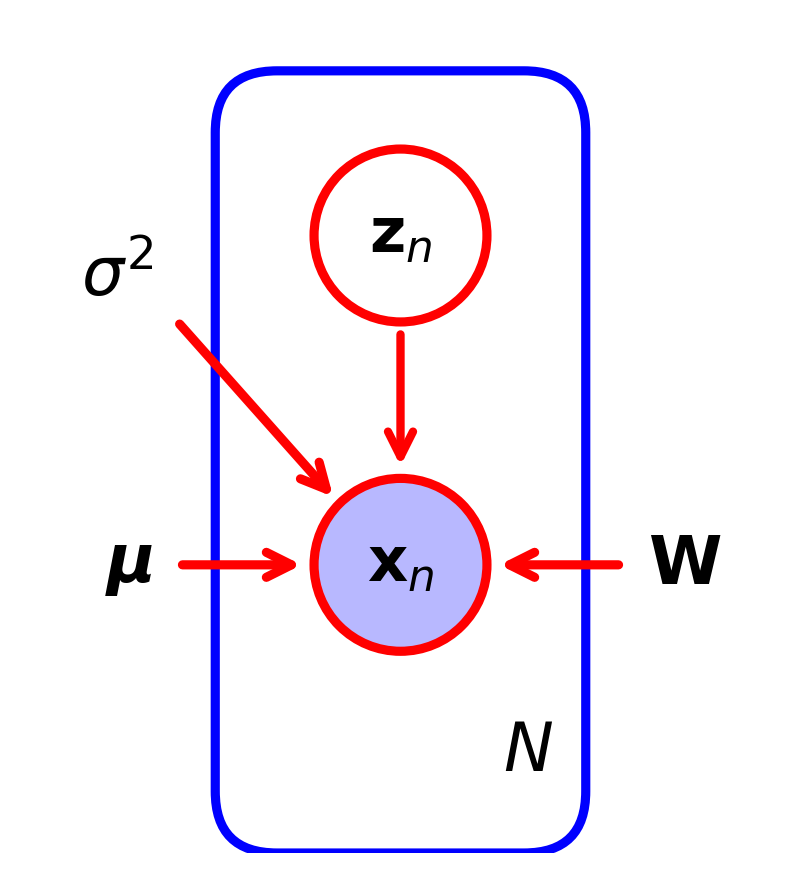

In [4]:
# Figure 16.8: 確率的主成分分析の有向確率的グラフィカルモデル
fig16_8 = generate_figure_16_8()
plt.show()


### パラメータの最尤解

1. **平均ベクトル $\boldsymbol{\mu}_{\text{ML}}$**:
   対数尤度を $\boldsymbol{\mu}$ で微分して 0 と置くと、標本平均に一致します：
   $$
   \boldsymbol{\mu}_{\text{ML}} = \bar{\mathbf{x}} = \frac{1}{N}\sum_{n=1}^N \mathbf{x}_n \tag{16.1}
   $$
   対数尤度は $\boldsymbol{\mu}$ に関して上に凸な2次形式であるため、これは大域的唯一の最大値です。

2. **標本共分散行列 $\mathbf{S}$ による表現**:
   $\boldsymbol{\mu} = \bar{\mathbf{x}}$ を代入し、トレースの巡回対称性 $\mathbf{a}^\top \mathbf{B} \mathbf{a} = \operatorname{Tr}(\mathbf{B} \mathbf{a}\mathbf{a}^\top)$ を用いると、対数尤度関数は標本共分散行列 $\mathbf{S} = \frac{1}{N}\sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})(\mathbf{x}_n - \bar{\mathbf{x}})^\top$ を用いてエレガントに記述されます：
   $$
   \ln p(\mathbf{X} \mid \mathbf{W}, \bar{\mathbf{x}}, \sigma^2) = -\frac{N}{2}\left[ D\ln(2\pi) + \ln|\mathbf{C}| + \operatorname{Tr}(\mathbf{C}^{-1}\mathbf{S}) \right] \tag{16.45}
   $$

3. **$\mathbf{W}$ および $\sigma^2$ の厳密閉形式解 (Tipping & Bishop, 1999)**:
   対数尤度関数 (16.45) を $\mathbf{W}$ および $\sigma^2$ に関して最大化する極値問題は非自明ですが、**厳密な閉形式解（exact closed-form solution）**が存在することが Tipping & Bishop (1999) によって証明されました：

   $$
   \mathbf{W}_{\text{ML}} = \mathbf{U}_M (\mathbf{L}_M - \sigma^2 \mathbf{I}_M)^{1/2} \mathbf{R} \tag{16.46}
   $$

   $$
   \sigma_{\text{ML}}^2 = \frac{1}{D - M} \sum_{i=M+1}^D \lambda_i \tag{16.47}
   $$

   ここで：
   - $\mathbf{U}_M \in \mathbb{R}^{D \times M}$: 標本共分散行列 $\mathbf{S}$ の**固有値上位 $M$ 個に対応する正規化直交固有ベクトル**を並べた行列。
   - $\mathbf{L}_M = \operatorname{diag}(\lambda_1, \dots, \lambda_M)$: 上位 $M$ 個の固有値（$\lambda_1 \ge \cdots \ge \lambda_M$）。
   - $\mathbf{R} \in \mathbb{R}^{M \times M}$: 任意の直交行列（通常は便宜上 $\mathbf{R} = \mathbf{I}_M$ を選択）。
   - $\sigma_{\text{ML}}^2$: **捨てられた $D - M$ 個の固有値の算術平均**（主部分空間外の平均残留ノイズ分散）。

---

### 最尤解の幾何学的・統計的性質

1. **主成分方向の分散の一致**:
   主部分空間を張る各固有ベクトル $\mathbf{u}_i$ ($i \le M$) に沿ったモデル予測分散は：
   $$
   \mathbf{u}_i^\top \mathbf{C} \mathbf{u}_i = \mathbf{u}_i^\top (\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I})\mathbf{u}_i = (\lambda_i - \sigma^2) + \sigma^2 = \lambda_i
   $$
   となり、データの標本分散と完全に一致します。
   一方、主部分空間に直交する任意の単位ベクトル $\mathbf{v}$ ($\mathbf{v} \perp \mathbf{u}_i$) に対しては：
   $$
   \mathbf{v}^\top \mathbf{C} \mathbf{v} = \sigma^2
   $$
   となり、モデルは主軸方向の分散を忠実に保持しながら、直交方向のばらつきを一様な平均分散 $\sigma^2$ で滑らかに近似します。

2. **$M = D$ の極限**:
   $M = D$ のとき $\mathbf{U}_M = \mathbf{U}, \mathbf{L}_M = \mathbf{L}$ となり、
   $$
   \mathbf{C} = \mathbf{U}(\mathbf{L} - \sigma^2 \mathbf{I})^{1/2}\mathbf{R}\mathbf{R}^\top(\mathbf{L} - \sigma^2 \mathbf{I})^{1/2}\mathbf{U}^\top + \sigma^2 \mathbf{I} = \mathbf{U}\mathbf{L}\mathbf{U}^\top = \mathbf{S} \tag{16.48}
   $$
   制約のない一般の多変量正規分布の最尤解（標本共分散）と完全に一致します。

3. **事後射影とゼロノイズ極限 (Shrinkage Effect)**:
   データ点 $\mathbf{x}$ の潜在空間への事後平均は：
   $$
   \mathbb{E}[\mathbf{z} \mid \mathbf{x}] = \mathbf{M}^{-1} \mathbf{W}_{\text{ML}}^\top (\mathbf{x} - \bar{\mathbf{x}}) \tag{16.49}
   $$
   この点をデータ空間へ再構成すると：
   $$
   \hat{\mathbf{x}} = \mathbf{W}_{\text{ML}} \mathbb{E}[\mathbf{z} \mid \mathbf{x}] + \bar{\mathbf{x}} \tag{16.50}
   $$
   ここでノイズ分散を $\sigma^2 \to 0$ とすると、$\mathbf{M} \to \mathbf{W}_{\text{ML}}^\top \mathbf{W}_{\text{ML}}$ となり：
   $$
   \mathbb{E}[\mathbf{z} \mid \mathbf{x}] \to (\mathbf{W}_{\text{ML}}^\top \mathbf{W}_{\text{ML}})^{-1}\mathbf{W}_{\text{ML}}^\top (\mathbf{x} - \bar{\mathbf{x}}) \tag{16.51}
   $$
   これは**従来の決定論的PCAの直交射影公式と厳密に一致**します！
   $\sigma^2 > 0$ の場合、$(\mathbf{W}^\top \mathbf{W} + \sigma^2 \mathbf{I})^{-1}$ の存在によって、射影点は直交射影よりも原点側（事前分布平均）へと引き戻される**縮小推定（shrinkage）**が生じます。これはリッジ回帰（第4章）の正則化効果と数学的に同型です。

4. **独立パラメータ数（自由度）**:
   $\mathbf{W}$ ($D \times M$) と $\sigma^2$ (1個) の合計 $DM + 1$ から、直交行列 $\mathbf{R}$ の自由度 $M(M-1)/2$ を差し引くことで：
   $$
   N_{\text{params}} = DM + 1 - \frac{M(M - 1)}{2} \tag{16.52}
   $$
   $M$ を固定すればパラメータ数は次元数 $D$ に対して**線形（$\mathcal{O}(D)$）**にしかなりません。
   $M = D - 1$ のときは $D(D-1) + 1 - (D-1)(D-2)/2 = D(D+1)/2$ となり、完全共分散行列の独立パラメータ数と一致します。


=== Old Faithful PPCA (M=1) ===
Data mean mu: [ 3.48778309 70.89705882]
Factor loadings W:
[[ 1.02694693]
 [13.5609917 ]]
Noise variance sigma^2: 0.2433
Degrees of freedom: 3
Log-likelihood: -1289.80


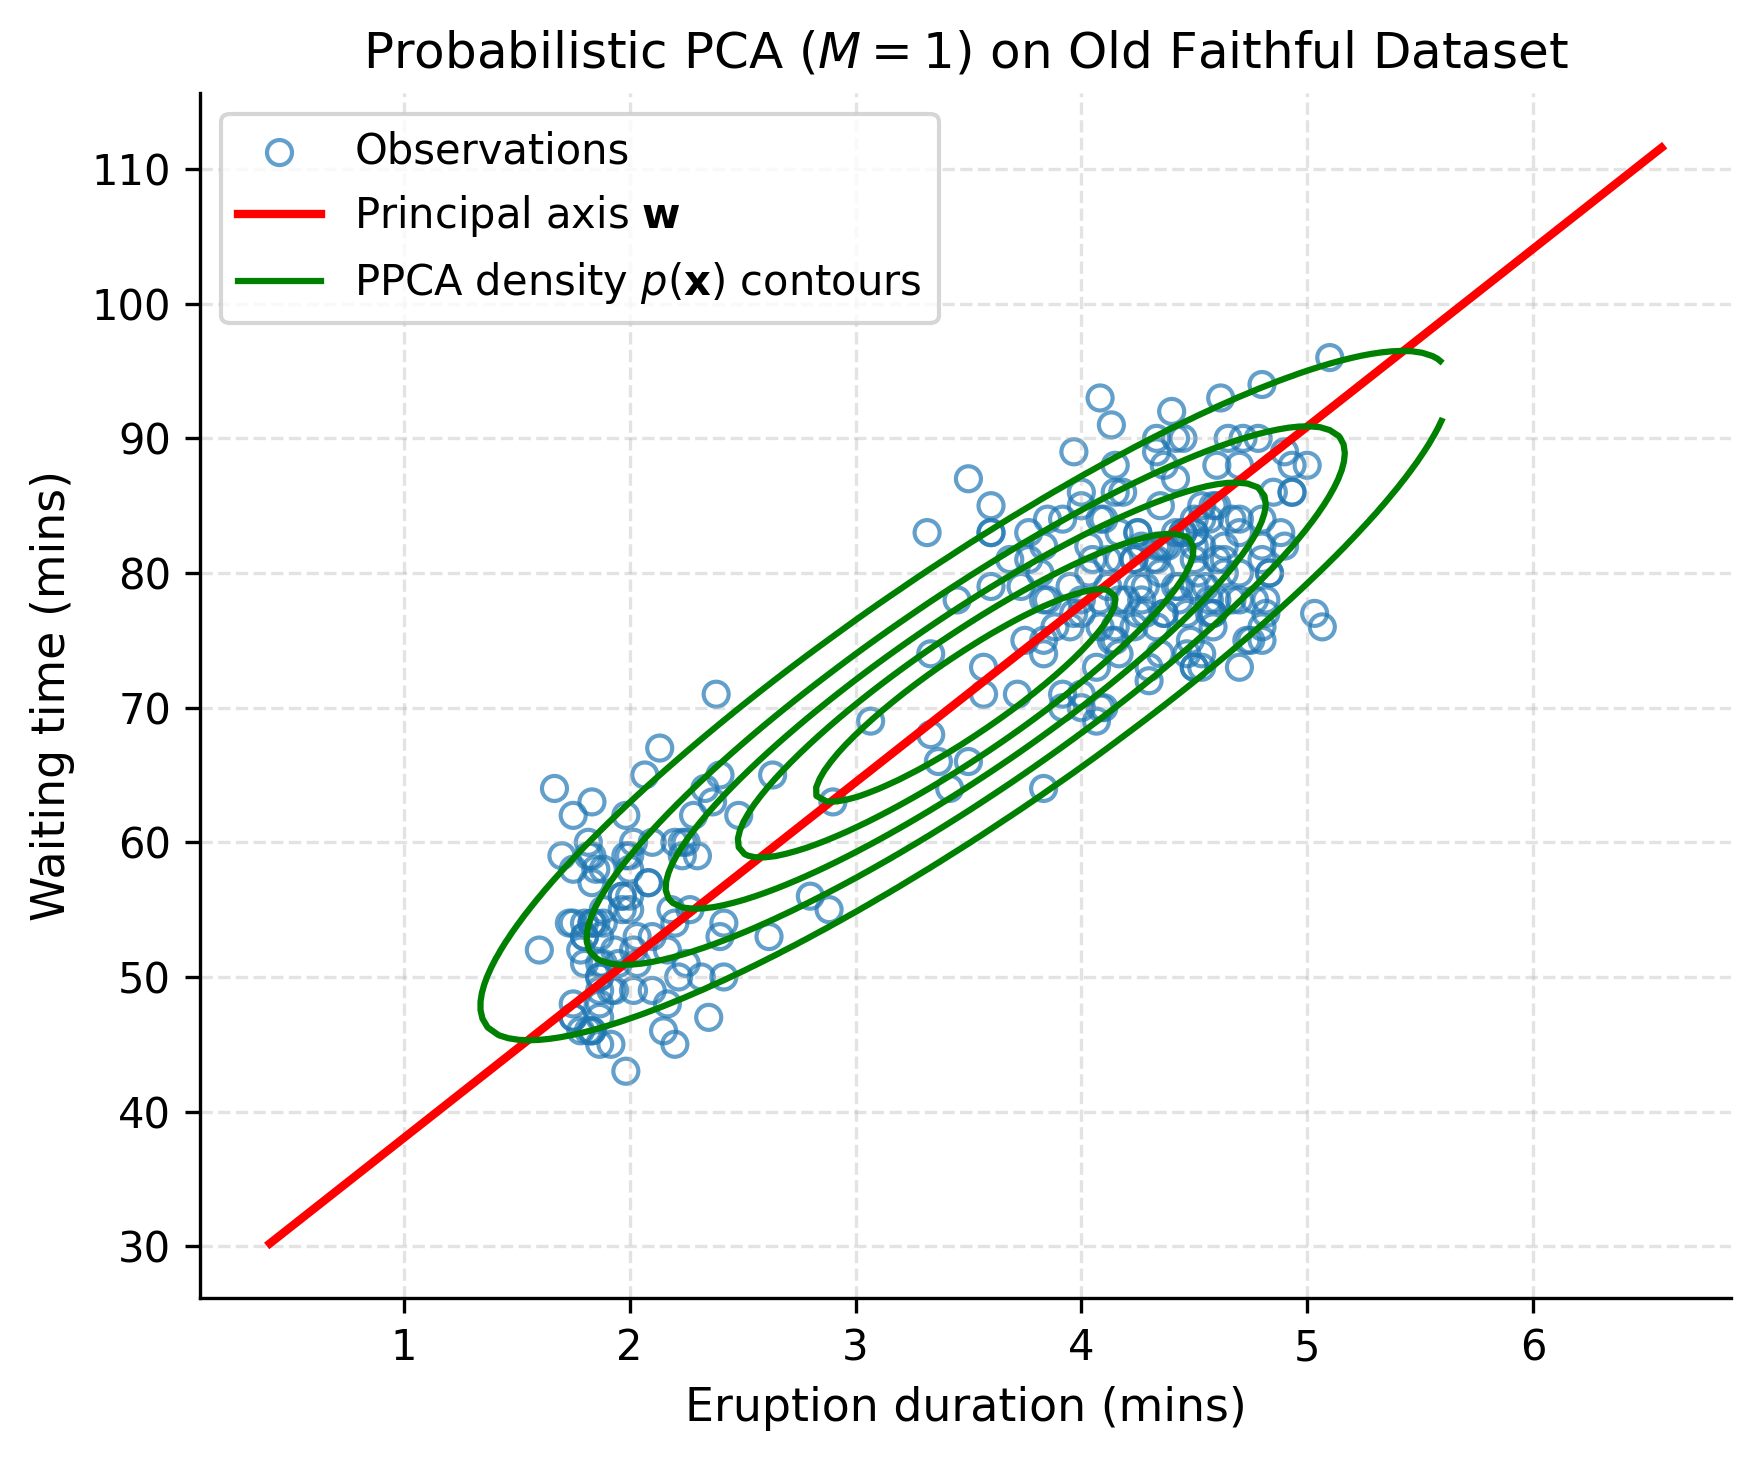

In [5]:
# Old Faithful データセットに対する PPCA (M=1) のフィッティングと可視化
from common.principal_component_analysis import _get_faithful_csv_path

csv_path = _get_faithful_csv_path()
df = pd.read_csv(csv_path)
X_faithful = df[["duration", "waiting"]].to_numpy(dtype=np.float64)

ppca = ProbabilisticPCA(n_components=1)
ppca.fit(X_faithful)

print("=== Old Faithful PPCA (M=1) ===")
print(f"Data mean mu: {ppca.mu_}")
print(f"Factor loadings W:\n{ppca.W_}")
print(f"Noise variance sigma^2: {ppca.sigma2_:.4f}")
print(f"Degrees of freedom: {ppca.degrees_of_freedom()}")
print(f"Log-likelihood: {ppca.log_likelihood():.2f}")

# プロット: データ点、主軸、および PPCA 周辺分布の楕円等高線
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
ax.scatter(X_faithful[:, 0], X_faithful[:, 1], facecolors="none", edgecolors="#1f77b4", alpha=0.7, label="Observations")

# 主軸 W の方向ベクトル
mu = ppca.mu_
w = ppca.W_[:, 0]
t = np.linspace(-3, 3, 100)
line = mu[:, None] + w[:, None] * t
ax.plot(line[0], line[1], color="red", lw=2, label=r"Principal axis $\mathbf{w}$")

# 周辺共分散 C の等高線を描画
x_grid = np.linspace(X_faithful[:, 0].min() - 0.5, X_faithful[:, 0].max() + 0.5, 100)
y_grid = np.linspace(X_faithful[:, 1].min() - 5, X_faithful[:, 1].max() + 5, 100)
XG, YG = np.meshgrid(x_grid, y_grid)
grid_pts = np.column_stack([XG.ravel(), YG.ravel()])
log_prob_grid = ppca.score_samples(grid_pts).reshape(XG.shape)

ax.contour(XG, YG, np.exp(log_prob_grid), levels=5, colors="green", linewidths=1.5)
ax.plot([], [], color="green", lw=1.5, label=r"PPCA density $p(\mathbf{x})$ contours")

ax.set_xlabel("Eruption duration (mins)", fontsize=11)
ax.set_ylabel("Waiting time (mins)", fontsize=11)
ax.set_title("Probabilistic PCA ($M=1$) on Old Faithful Dataset", fontsize=12)
ax.legend(frameon=True, fontsize=10)
plt.show()


## 4. 16.2.4 因子分析 (Factor Analysis)

**因子分析 (Factor Analysis: FA)** は、PPCAと極めて密接に関連する線形ガウス潜在変数モデルです。
両者の唯一の違いは、観測ノイズ共分散行列の仮定にあります。PPCAが等方性ノイズ $\sigma^2 \mathbf{I}_D$ を仮定するのに対し、因子分析では**各特徴量ごとに異なる固有のノイズ分散**を持つ対角共分散行列 $\mathbf{\Psi}$ を仮定します：

$$
p(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(\mathbf{x} \mid \mathbf{W}\mathbf{z} + \boldsymbol{\mu}, \mathbf{\Psi}) \tag{16.53}
$$

$$
\mathbf{\Psi} = \operatorname{diag}(\psi_1^2, \dots, \psi_D^2)
$$

観測データの周辺分布は：

$$
p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \mathbf{C}), \quad \mathbf{C} = \mathbf{W}\mathbf{W}^\top + \mathbf{\Psi} \tag{16.54}
$$

- 行列 $\mathbf{W}$ の列ベクトルは**因子負荷量 (factor loadings)** と呼ばれ、観測変数間の相互相関（共分散構造）を担います。
- 対角行列 $\mathbf{\Psi}$ の各要素 $\psi_d^2$ は**独自性 (uniquenesses)** または固有分散と呼ばれ、各変数特有の独立なノイズを担います。

### PPCA と 因子分析の決定的違い：スケーリング不変性

- **PPCA**: データ空間の直交回転に対して不変。しかし各変数のスケール変更（単位系の変更など）に対しては不変ではない。
- **因子分析**: 各成分ごとのスケール変換（成分ごとの拡大・縮小 $x_d \to c_d x_d$）に対して不変！各要素のスケール変更は $\mathbf{\Psi}$ の対角成分のスケール変更 $\psi_d^2 \to c_d^2 \psi_d^2$ および $\mathbf{w}_d \to c_d \mathbf{w}_d$ にそのまま吸収されます。

因子分析のパラメータ学習には、次節（16.3節）で詳述するEMアルゴリズムが標準的に用いられます。


In [6]:
# 因子分析モデルの学習とPPCAとの比較
rng = np.random.default_rng(42)
N, D, M = 300, 4, 2
Z_true = rng.standard_normal((N, M))
W_true = np.array([
    [2.0, 0.2],
    [1.5, -1.0],
    [0.1, 1.8],
    [-1.2, 0.5]
])
# 異分散性ノイズ（第4成分のノイズが特に大きい）
psi_true = np.array([0.05, 0.1, 0.08, 0.8])
X_fa = Z_true @ W_true.T + rng.normal(0, np.sqrt(psi_true), size=(N, D))

fa = FactorAnalysisModel(n_components=2, max_iter=80).fit(X_fa)
ppca_comp = ProbabilisticPCA(n_components=2).fit(X_fa)

print("=== Estimated Uniquenesses Psi in Factor Analysis ===")
print("True Psi:     ", psi_true)
print("Estimated Psi:", np.round(fa.psi_, 4))
print(f"PPCA isotropic sigma^2: {ppca_comp.sigma2_:.4f}")
print("Factor analysis captures individual variable variances successfully.")


=== Estimated Uniquenesses Psi in Factor Analysis ===
True Psi:      [0.05 0.1  0.08 0.8 ]
Estimated Psi: [0.0724 0.094  0.1137 0.7549]
PPCA isotropic sigma^2: 0.3499
Factor analysis captures individual variable variances successfully.


## 5. 16.2.5 独立成分分析 (Independent Component Analysis: ICA)

線形ガウス潜在変数モデル（PPCAおよび因子分析）では、潜在変数の事前分布 $p(\mathbf{z})$ が等方性ガウス分布 $\mathcal{N}(\mathbf{0}, \mathbf{I})$ であったため、潜在空間の任意の回転 $\mathbf{W} \to \mathbf{W}\mathbf{R}$ に対して周辺尤度が不変となり、**個別の潜在軸の物理的意味を分離・特定することは原理的に不可能**でした。

この回転の縮退（統計的非識別性）を打破し、個別の独立な潜在信号を特定するために考案されたのが**独立成分分析 (Independent Component Analysis: ICA)** です。
ICAでは、潜在変数 $\mathbf{z} = (z_1, \dots, z_M)^\top$ の事前分布が完全に因子分解することを仮定します：

$$
p(\mathbf{z}) = \prod_{j=1}^M p(z_j) \tag{16.55}
$$

### なぜガウス分布では不十分なのか？

もし各 $p(z_j)$ がガウス分布であれば、$p(\mathbf{z}) = \prod \mathcal{N}(z_j \mid 0, 1) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I})$ となり、回転対称性が保存されてしまいます。
独立成分を一意に分離するためには、各潜在変数 $z_j$ が**非ガウス型分布 (non-Gaussian distribution)** に従うことが数学的必要十分条件となります。
実世界データでは、ガウス分布に比べて裾が重い（heavy-tailed）分布が頻出し、教科書では以下の分布が代表例として挙げられています：

$$
p(z_j) = \frac{1}{\pi \cosh(z_j)} = \frac{2}{\pi (e^{z_j} + e^{-z_j})} \tag{16.56}
$$

### カクテルパーティー問題 (Cocktail Party Problem)

2つの独立な音声信号 $s_1(t), s_2(t)$ が2本のマイクで線形混合されて観測された場合（ブラインド信号源分離：Blind Source Separation: BSS）：
$$
\mathbf{x}(t) = \mathbf{A} \mathbf{s}(t)
$$
FastICA等のアルゴリズムにより、混合行列の逆行列（アンミキシング行列 $\mathbf{W}_{\text{ICA}}$）を非ガウス性（尖度やネゲントロピー）の最大化によって学習し、元のクリーンな信号を復元できます。


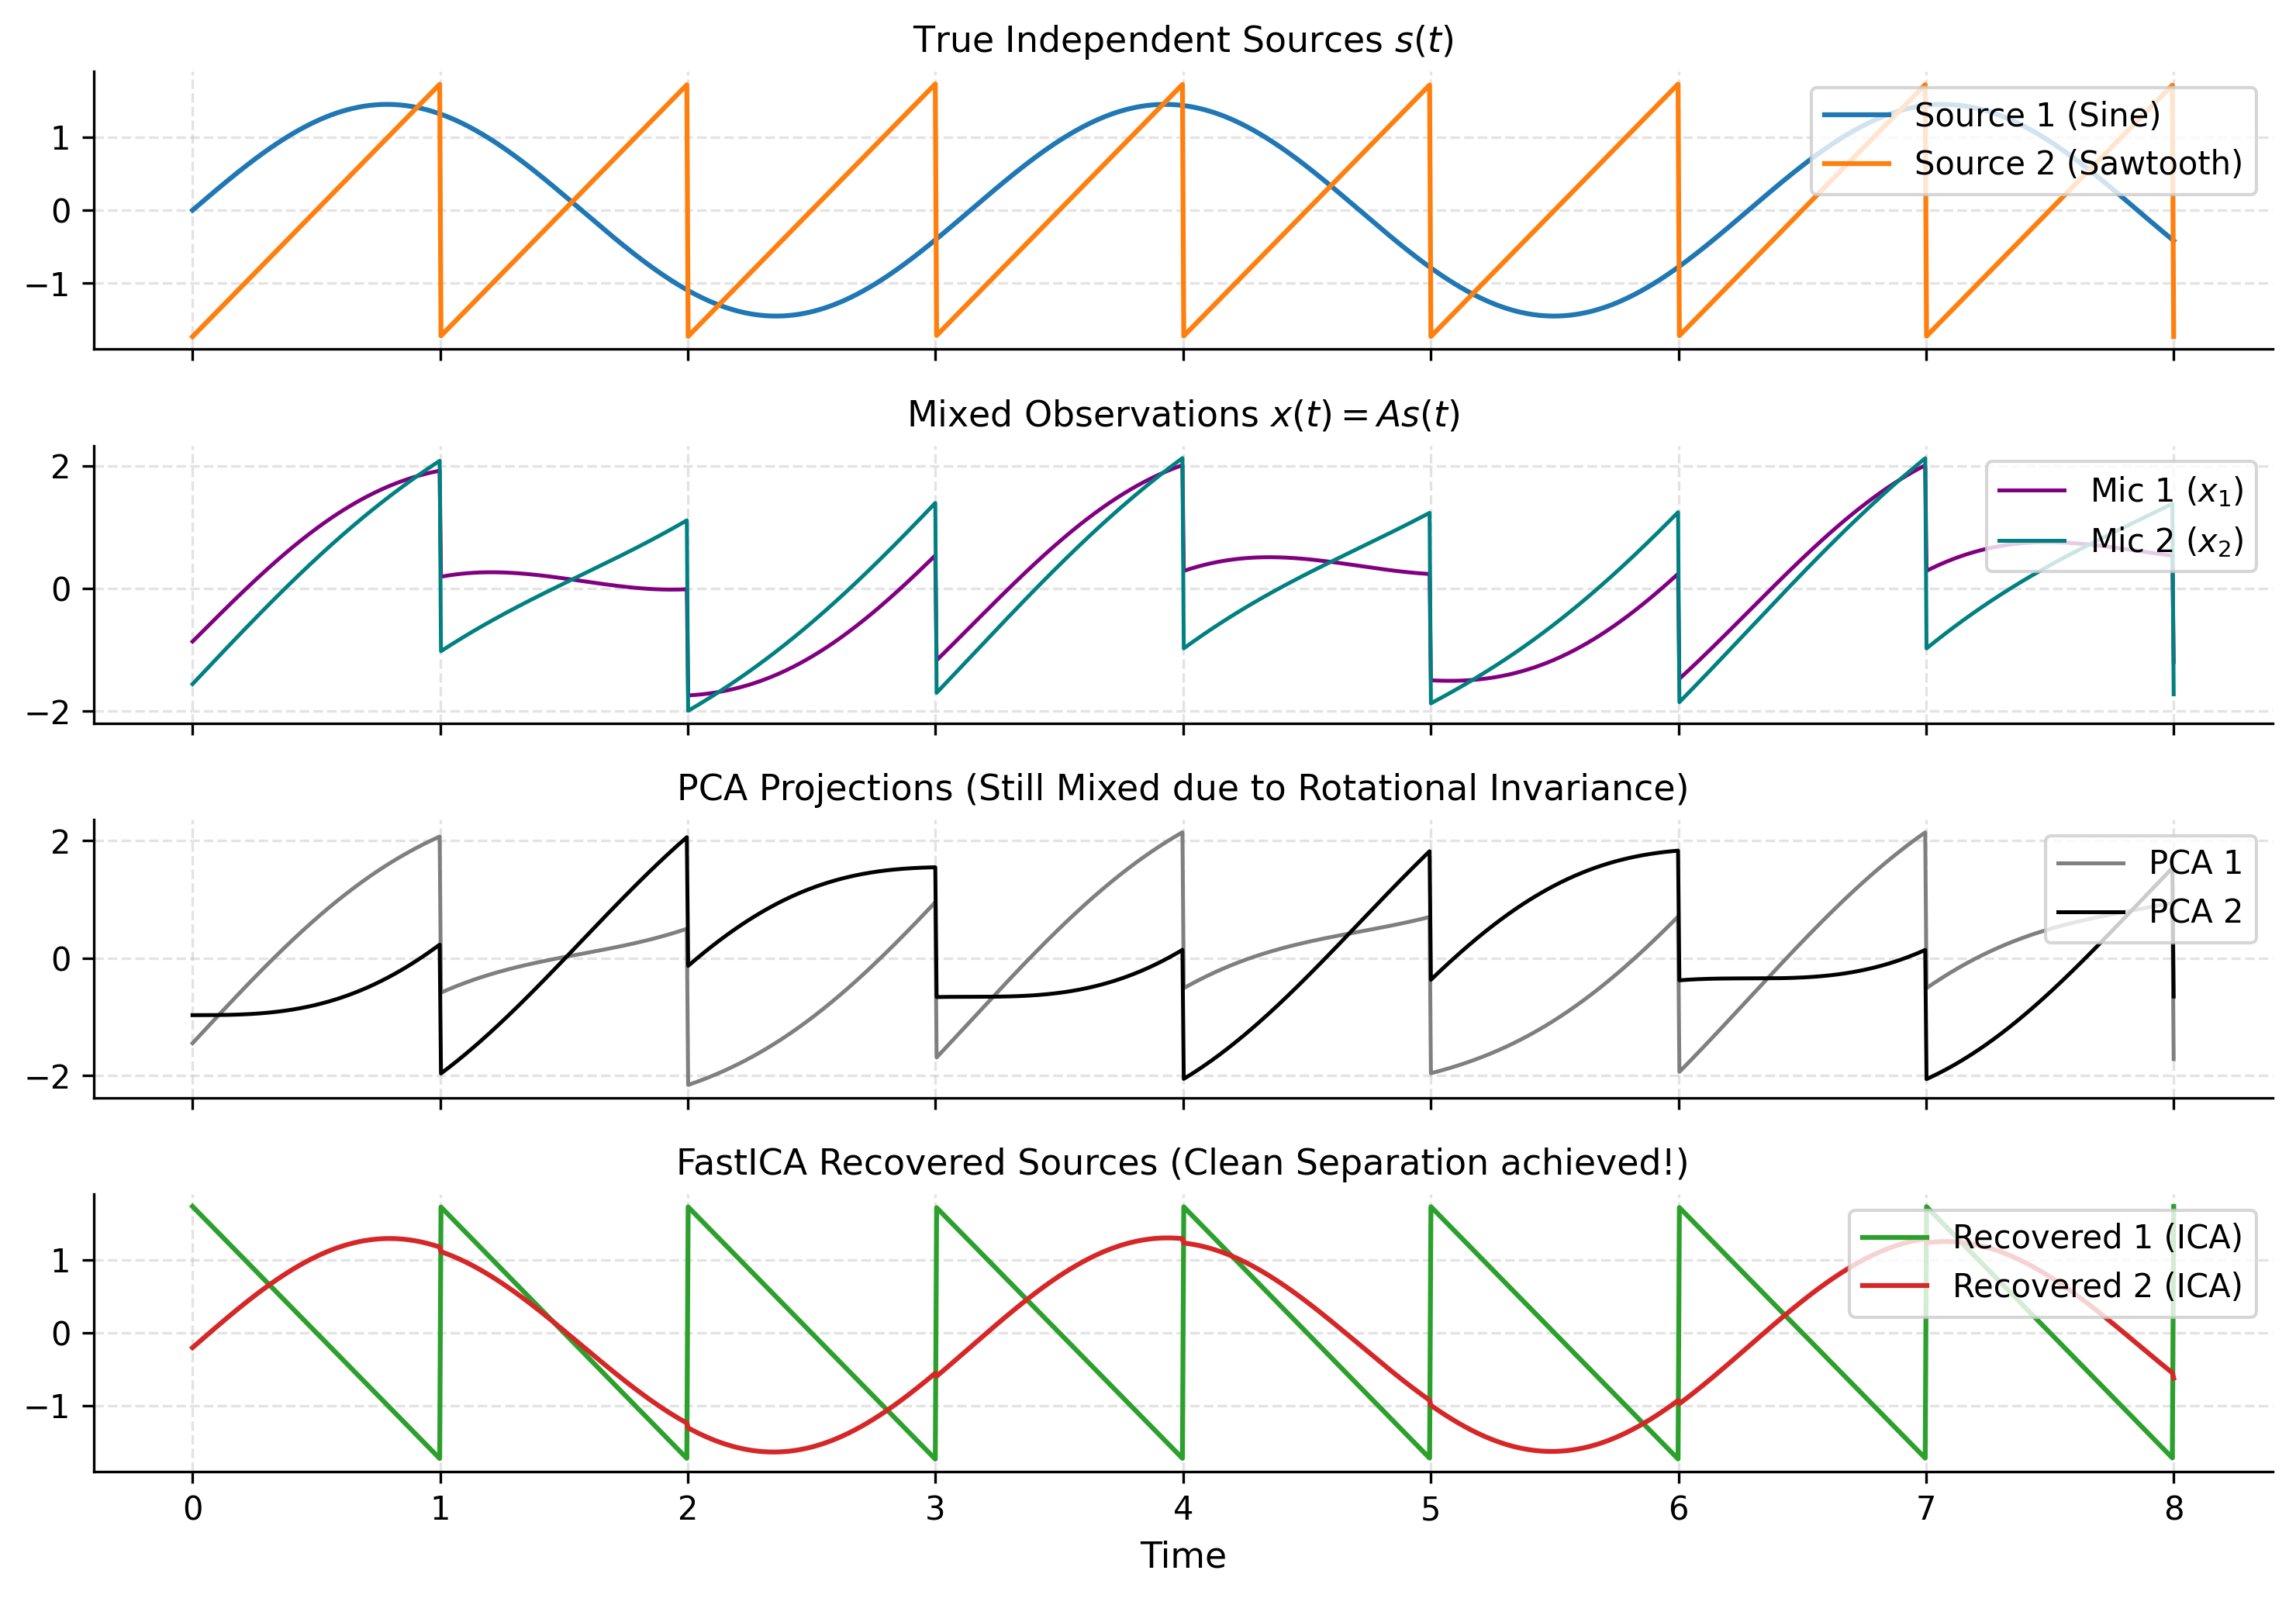

In [7]:
# 独立成分分析 (FastICA) によるブラインド信号源分離の実証
n_samples = 1500
time = np.linspace(0, 8, n_samples)

# 2つの非ガウス独立信号: 正弦波とノコギリ波
s1 = np.sin(2 * time)
s2 = 2.0 * (time % 1.0) - 1.0
S_true = np.vstack([s1, s2]).T
S_true /= S_true.std(axis=0)

# 混合行列 A
A = np.array([[0.8, 0.5], [0.4, 0.9]])
X_mixed = S_true @ A.T

# 1. PCA による分離試行（無相関化のみで独立化できず失敗）
ppca_test = ProbabilisticPCA(n_components=2).fit(X_mixed)
S_pca = ppca_test.transform(X_mixed)

# 2. FastICA による分離
ica = FastICA2D(random_state=42)
S_ica = ica.fit_transform(X_mixed)
S_ica /= S_ica.std(axis=0)

# プロット比較
fig, axes = plt.subplots(4, 1, figsize=(10, 7), dpi=300, sharex=True)
axes[0].plot(time, S_true[:, 0], color="tab:blue", lw=1.5, label="Source 1 (Sine)")
axes[0].plot(time, S_true[:, 1], color="tab:orange", lw=1.5, label="Source 2 (Sawtooth)")
axes[0].set_title("True Independent Sources $s(t)$", fontsize=11)
axes[0].legend(loc="upper right")

axes[1].plot(time, X_mixed[:, 0], color="purple", lw=1.2, label="Mic 1 ($x_1$)")
axes[1].plot(time, X_mixed[:, 1], color="teal", lw=1.2, label="Mic 2 ($x_2$)")
axes[1].set_title("Mixed Observations $x(t) = A s(t)$", fontsize=11)
axes[1].legend(loc="upper right")

axes[2].plot(time, S_pca[:, 0], color="tab:gray", lw=1.2, label="PCA 1")
axes[2].plot(time, S_pca[:, 1], color="black", lw=1.2, label="PCA 2")
axes[2].set_title("PCA Projections (Still Mixed due to Rotational Invariance)", fontsize=11)
axes[2].legend(loc="upper right")

axes[3].plot(time, S_ica[:, 0], color="tab:green", lw=1.5, label="Recovered 1 (ICA)")
axes[3].plot(time, S_ica[:, 1], color="tab:red", lw=1.5, label="Recovered 2 (ICA)")
axes[3].set_title("FastICA Recovered Sources (Clean Separation achieved!)", fontsize=11)
axes[3].set_xlabel("Time", fontsize=11)
axes[3].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 6. 16.2.6 カルマンフィルタ (Kalman Filters / Linear Dynamical Systems)

これまでのモデルは、データ点が独立同分布 (i.i.d.) であることを前提としていました。しかし、時系列データやセンサトラッキング等では、時間的な順序と系列相関が存在します。

第15章（15.3.1項）で離散混合モデルを系列データに拡張して**隠れマルコフモデル (Hidden Markov Model: HMM)** を構築したのと全く同様に、**連続潜在変数モデルの潜在変数をマルコフ連鎖として時間方向に接続したもの**が**線形動的システム (Linear Dynamical System: LDS)**、別名**カルマンフィルタ (Kalman Filter)** です（Figure 16.9）。

| モデル | 潜在空間の性質 | 系列構造なし (i.i.d.) | 系列構造あり (Markov Chain) |
|---|---|---|---|
| **離散潜在変数** | 離散カテゴリ $k \in \{1,\dots,K\}$ | 混合ガウスモデル (GMM) | 隠れマルコフモデル (HMM) |
| **連続潜在変数** | 連続ベクトル $\mathbf{z} \in \mathbb{R}^M$ | 確率的主成分分析 (PPCA) | カルマンフィルタ (LDS) |

下図（Figure 16.9）は、この線形動的システムの確率的グラフィカルモデルです。
潜在状態が $\mathbf{z}_1 \to \mathbf{z}_2 \to \cdots \to \mathbf{z}_N$ のマルコフ遷移を形成し、各時点 $n$ で連続観測値 $\mathbf{x}_n$ が生成されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_9_kalman_graphical_model.png and /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_9_kalman_graphical_model.png


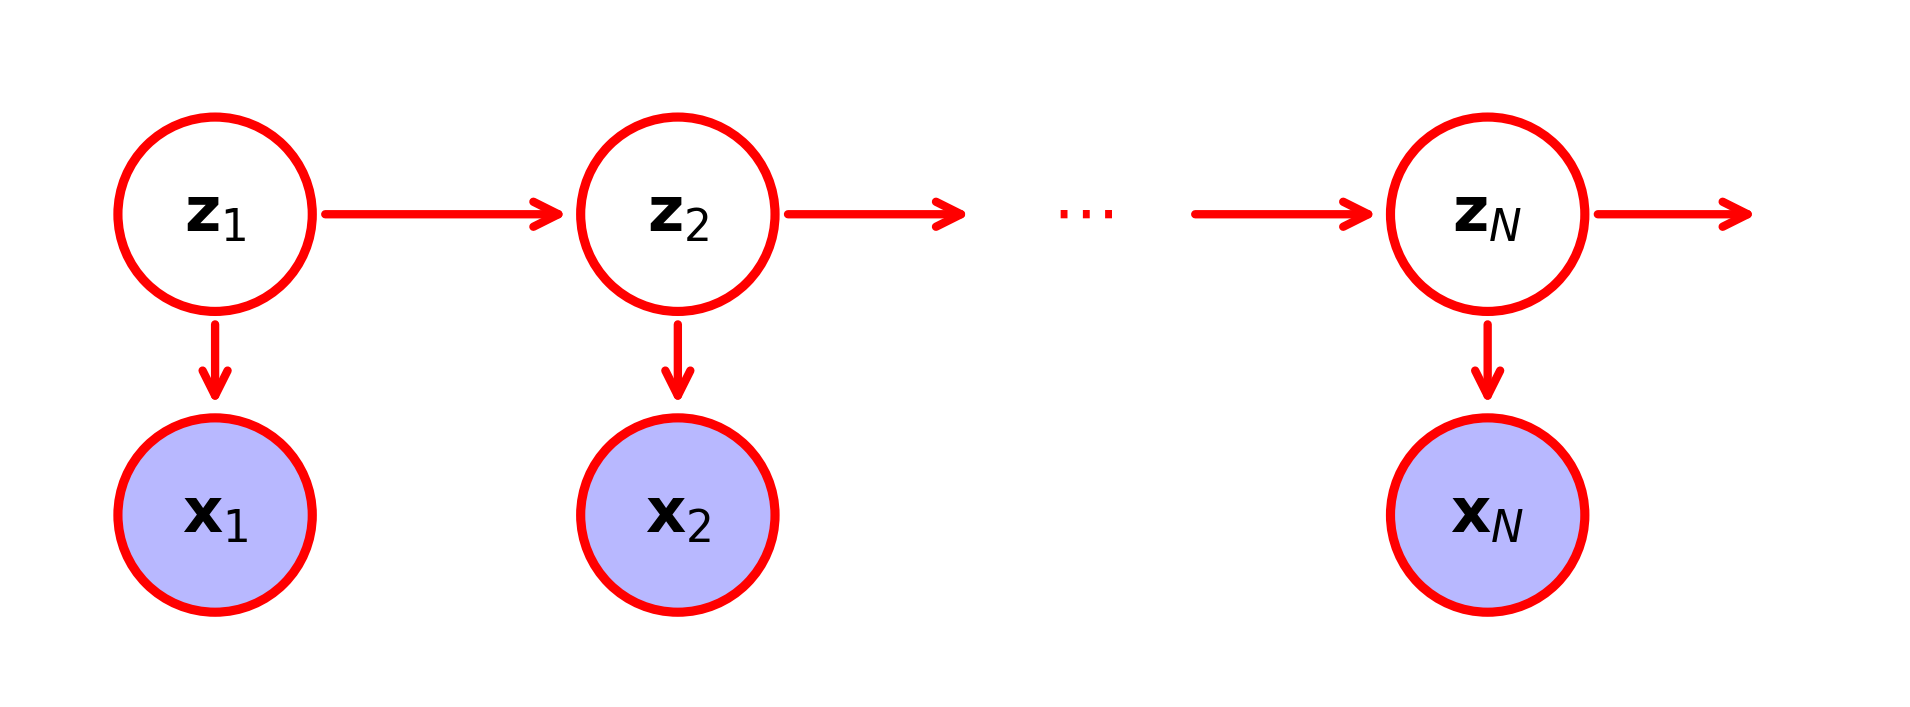

In [8]:
# Figure 16.9: カルマンフィルタ（線形動的システム）のグラフィカルモデル
fig16_9 = generate_figure_16_9()
plt.show()


### 1次元カルマンフィルタの状態推定シミュレーション

状態空間モデルの方程式：
- **状態遷移方程式**: $z_n = A z_{n-1} + w_n, \quad w_n \sim \mathcal{N}(0, \Gamma)$
- **観測方程式**: $x_n = C z_n + v_n, \quad v_n \sim \mathcal{N}(0, \Sigma)$

各ステップで**予測ステップ (Predict)** と **更新ステップ (Update)** を交互に実行することで、観測ノイズに汚染されたデータから真の潜在軌道を最適に復元します。


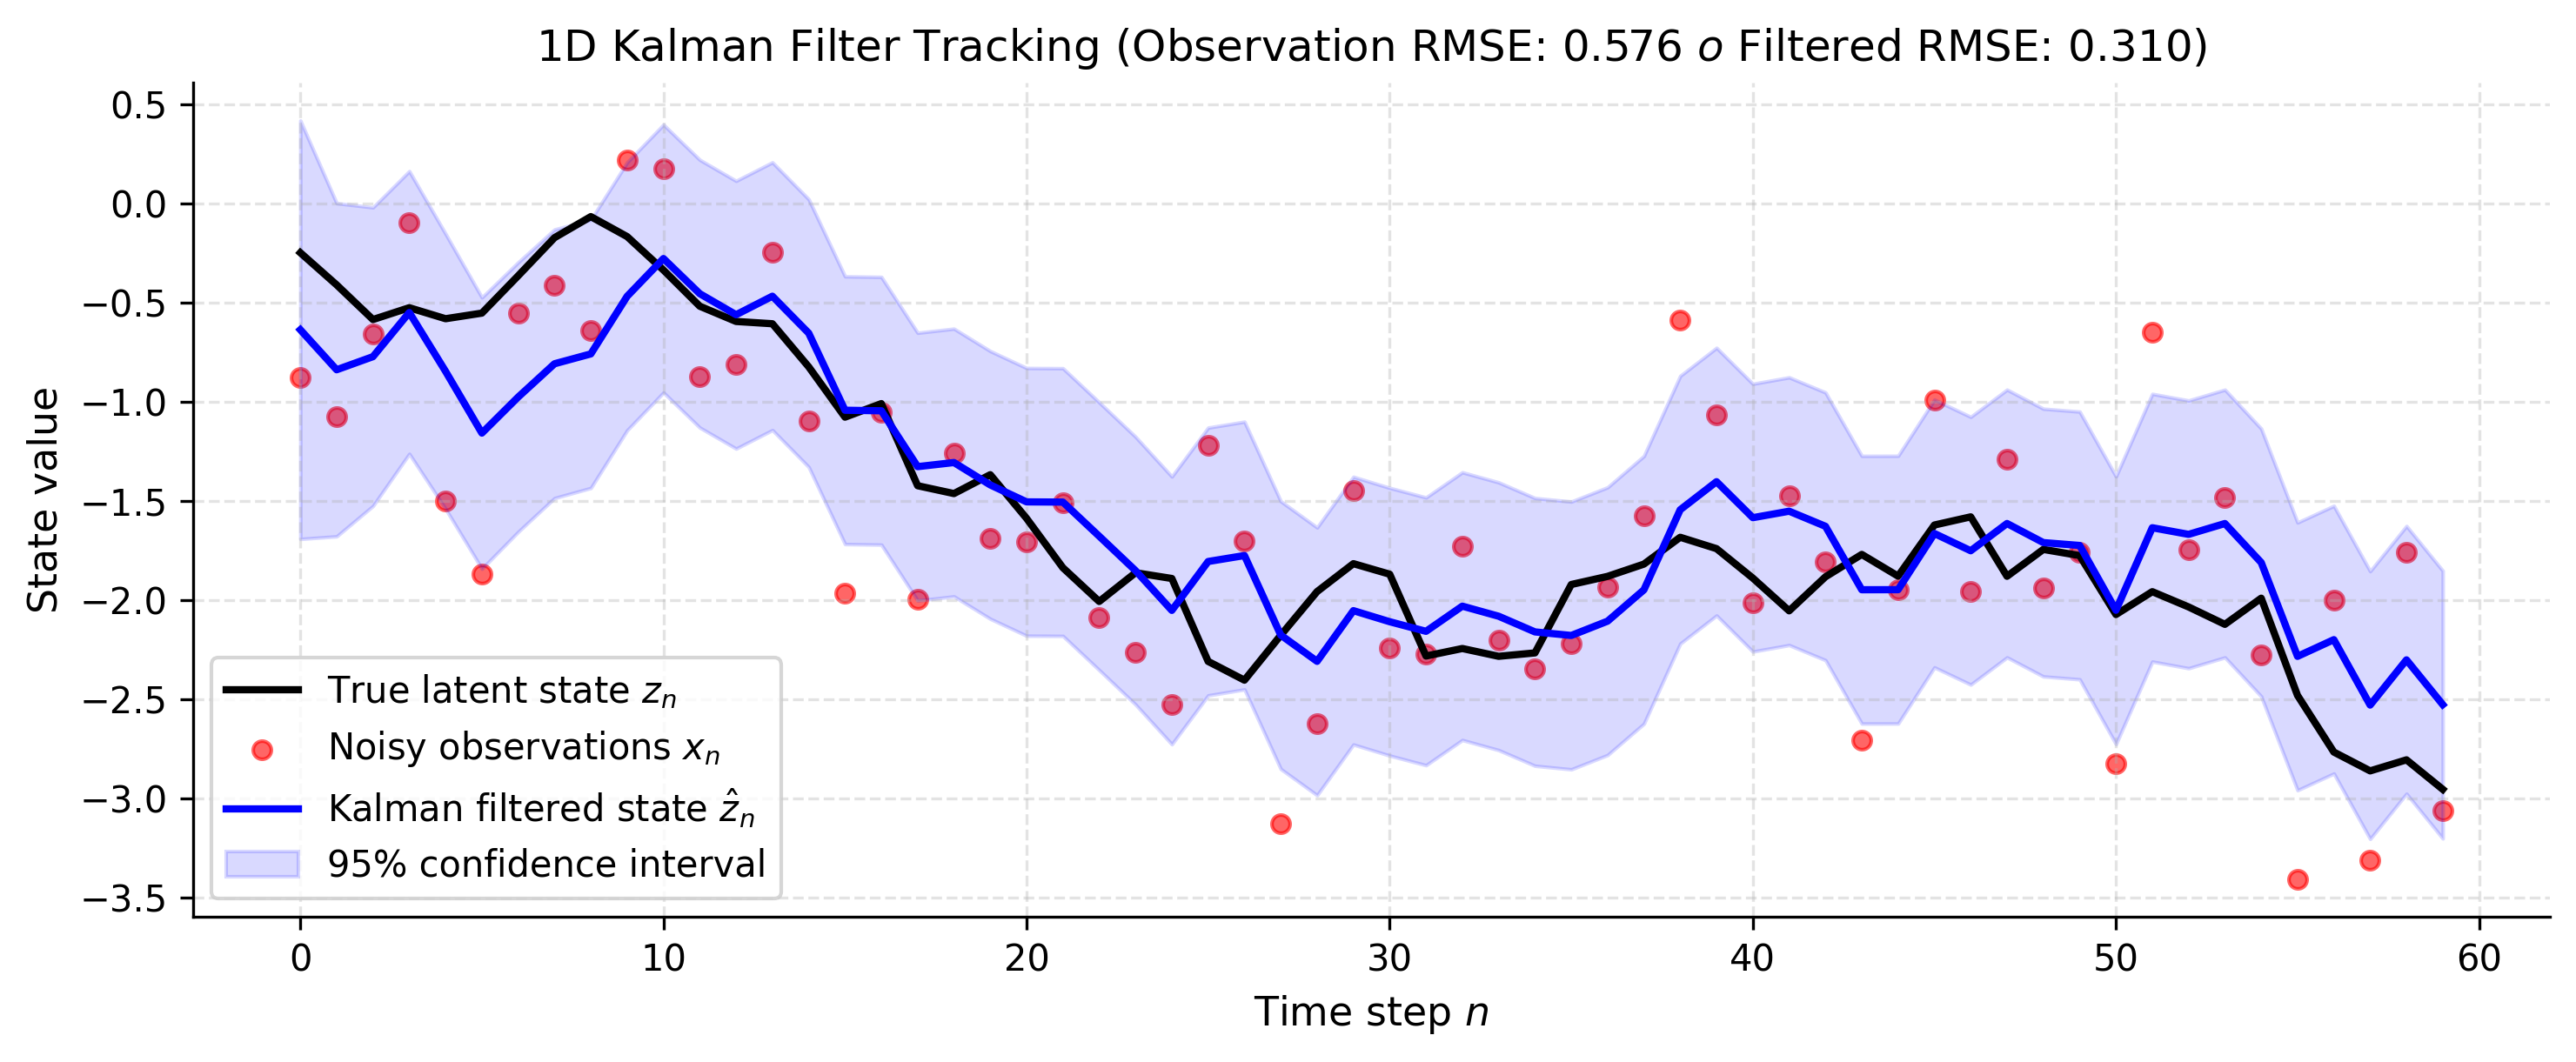

In [9]:
# カルマンフィルタによるノイズ除去と潜在状態追従シミュレーション
rng = np.random.default_rng(10)
N_steps = 60
A, C = 1.0, 1.0
Gamma, Sigma = 0.05, 0.4

# 真の軌道とノイズ観測値のシミュレーション
w = rng.normal(0, np.sqrt(Gamma), size=N_steps)
z_true = np.cumsum(w)
v = rng.normal(0, np.sqrt(Sigma), size=N_steps)
x_obs = C * z_true + v

# カルマンフィルタ実行
kf = KalmanFilter1D(A=A, C=C, Gamma=Gamma, Sigma=Sigma)
filtered_means, filtered_vars = kf.filter(x_obs, init_mean=0.0, init_var=1.0)
std_bounds = np.sqrt(filtered_vars)

# プロット
fig, ax = plt.subplots(figsize=(10, 4.2), dpi=300)
steps = np.arange(N_steps)

ax.plot(steps, z_true, "k-", lw=2, label="True latent state $z_n$")
ax.scatter(steps, x_obs, color="red", alpha=0.6, s=25, label="Noisy observations $x_n$")
ax.plot(steps, filtered_means, "b-", lw=2, label="Kalman filtered state $\hat{z}_n$")
ax.fill_between(steps, filtered_means - 1.96 * std_bounds, filtered_means + 1.96 * std_bounds,
                color="blue", alpha=0.15, label="95% confidence interval")

rmse_raw = np.sqrt(np.mean((x_obs - z_true)**2))
rmse_kf = np.sqrt(np.mean((filtered_means - z_true)**2))
ax.set_title(f"1D Kalman Filter Tracking (Observation RMSE: {rmse_raw:.3f} $	o$ Filtered RMSE: {rmse_kf:.3f})", fontsize=12)
ax.set_xlabel("Time step $n$", fontsize=11)
ax.set_ylabel("State value", fontsize=11)
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


## 7. まとめ

本節では、第16章「連続潜在変数」の中心的テーマである**確率的潜在変数モデル (Probabilistic Latent Variables)** について、以下の重要な結果を厳密に導出・実装・検証しました：

1. **生成モデルと幾何学的直観 (16.2.1)**:
   - 潜在事前分布 $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ と条件付きガウスノイズモデル $p(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(\mathbf{W}\mathbf{z} + \boldsymbol{\mu}, \sigma^2 \mathbf{I})$ による生成過程（式 16.31 〜 16.33）。
   - 主部分空間上にガウスインクを吹き付ける「パンケーキ型」確率密度の形成（Figure 16.7）。
2. **周辺尤度と計算効率 (16.2.2)**:
   - 周辺共分散 $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}$ の導出（式 16.36）。
   - ウッドベリーの公式による計算量の大幅削減 $\mathcal{O}(D^3) \to \mathcal{O}(M^3)$（式 16.41）。
   - 事後分布 $p(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}(\mathbf{M}^{-1}\mathbf{W}^\top(\mathbf{x} - \boldsymbol{\mu}), \sigma^2 \mathbf{M}^{-1})$（式 16.43）。
3. **厳密閉形式最尤解 (16.2.3)**:
   - 有向グラフィカルモデル（Figure 16.8）。
   - Tipping & Bishop (1999) による $\mathbf{W}_{\text{ML}} = \mathbf{U}_M(\mathbf{L}_M - \sigma^2 \mathbf{I})^{1/2}\mathbf{R}$ および $\sigma_{\text{ML}}^2 = \frac{1}{D-M}\sum_{i=M+1}^D \lambda_i$（式 16.46, 16.47）。
   - $\sigma^2 \to 0$ における標準直交射影PCAの完全復元と、$\sigma^2 > 0$ における縮小推定効果（式 16.51）。
   - 独立パラメータ数 $DM + 1 - M(M-1)/2$ による過学習抑制（式 16.52）。
4. **因子分析 (16.2.4)**:
   - 異分散対角ノイズ $\mathbf{\Psi}$ の導入と、成分ごとのスケーリング不変性（式 16.53, 16.54）。
5. **独立成分分析 (16.2.5)**:
   - ガウス潜在変数の回転対称性の限界と、非ガウス事前分布（式 16.55, 16.56）によるブラインド信号源分離。
6. **カルマンフィルタ (16.2.6)**:
   - 連続潜在空間のマルコフ連鎖化による線形動的システム（Figure 16.9）と時系列トラッキング。

次節（16.3節）では、これらのモデルをEMアルゴリズムの統一的枠組み（証拠下界: ELBO）から導出し、高次元データや欠損値データに対する効率的最適化手法について探究します。
